# Завдання 2. Оцінка A/B тесту частоти імейлів

Розрахунок строго за протоколом: `hypotheses/t2-ab-test.md`, розділ 8 (записаний до розрахунку).

**Що порівнюємо:** група b отримує імейли вдвічі частіше, ніж група a. Ефект — зміна метрики в b порівняно з a, %.

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd()
DATA, SQL, FIG = ROOT / "data", ROOT / "sql", ROOT / "figures"
FIG.mkdir(exist_ok=True)

N_BOOT = 10_000
CAP_Q = 0.999
WEIGHTS = {"revenue": 0.5, "payer": 0.2, "active_days": 0.3}
METRICS = ["revenue", "payer", "active_days", "episodes"]

COLORS = {"a": "#eb6834", "b": "#2a78d6"}
LABEL = {"new": "НОВІ", "old": "СТАРІ"}   # підписи на графіках
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#52514e", "axes.labelcolor": "#0b0b0b", "text.color": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "axes.grid": True,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "lines.linewidth": 2, "font.size": 10,
})
pd.options.display.float_format = "{:,.2f}".format

## 1. Таблиці метрик (SQL) і звірка з сирими даними
SQL-файли з `sql/` запускаються по черзі; звірка має дати нульову різницю в кожному рядку.

In [2]:
con = duckdb.connect()
con.execute(f"set file_search_path = '{DATA.as_posix()}'")
for f in sorted(SQL.glob("0*.sql")):
    con.execute(f.read_text(encoding="utf-8"))

checks = con.execute((SQL / "99_checks.sql").read_text(encoding="utf-8")).df()
checks["diff"] = checks.actual - checks.expected
assert (checks["diff"] == 0).all(), "звірка не зійшлась"
checks

,check_name,expected,actual,diff
0,усі користувачі розкладені по популяціях,"430,961.00","430,961.00",0.00
1,"у метриках — усі нові й старі, по одному рядку","389,515.00","389,515.00",0.00
2,виручка нових = сирі оплати у їхніх вікнах без...,"741,630.00","741,630.00",0.00
3,виручка старих у тесті = сирі оплати 01.08–25....,"1,353,510.00","1,353,510.00",0.00
4,виручка старих у базі = сирі оплати 18.07–31.07,"1,085,860.00","1,085,860.00",0.00
5,активні дні нових = сирі візити у їхніх вікнах,"512,828.00","512,828.00",0.00
6,епізоди старих у тесті = сирий лог 01.08–25.08,"1,044,529.00","1,044,529.00",0.00
7,денні нові: сума активних = сума активних днів...,"512,828.00","512,828.00",0.00
8,денні старі: виручка тесту = виручка тесту в м...,"1,353,510.00","1,353,510.00",0.00
9,нові 01–07.08: активні дні 0–6 = активні дні в...,"182,850.00","182,850.00",0.00


## 2. Огляд даних
Особливості даних, які визначають, як будується аналіз. Кожен пункт — факт на сирих даних.

In [3]:
users = con.execute("select * from read_csv_auto('users.csv')").df()
users["reg_date"] = users.created_at.dt.normalize()

def population(created_at):
    # старі зареєструвались до старту тесту, нові — після
    if created_at < pd.Timestamp("2022-08-01"):
        return "old"
    else:
        return "new"

users["population"] = users.created_at.apply(population)
users.population.value_counts()

population
new    237978
old    192983
Name: count, dtype: int64

**2.1 Поділ на групи.** Старі поділені 70/30, нові — 50/50.

In [4]:
split = pd.crosstab(users.population, users.split_group)
split["share_b_pct"] = 100 * split.b / (split.a + split.b)
split

split_group,a,b,share_b_pct
population,,,
new,118553,119425,50.18
old,135168,57815,29.96


**2.2 Згода на імейли.** Імейли отримують лише ті, хто дав згоду; частка однакова в a і b.

In [5]:
(100 * users.groupby(["population", "split_group"]).is_validated.mean()).unstack().round(1)

split_group,a,b
population,,
new,35.00,34.80
old,35.10,35.20


**2.3 Країна й ОС зв'язані.** Країна 1 — лише android, країна 3 — лише desktop: розрізів 4, а не 9.

In [6]:
pd.crosstab(users.country_code, users.default_os)

default_os,android,desktop,ios
country_code,,,
1,42931,0,0
2,172427,0,129251
3,0,86352,0


**2.4 Оплати по днях.** 14.08 і 15.08 оплат нема, хоча візити звичайні — втрата даних; ці дні не входять у виручку.

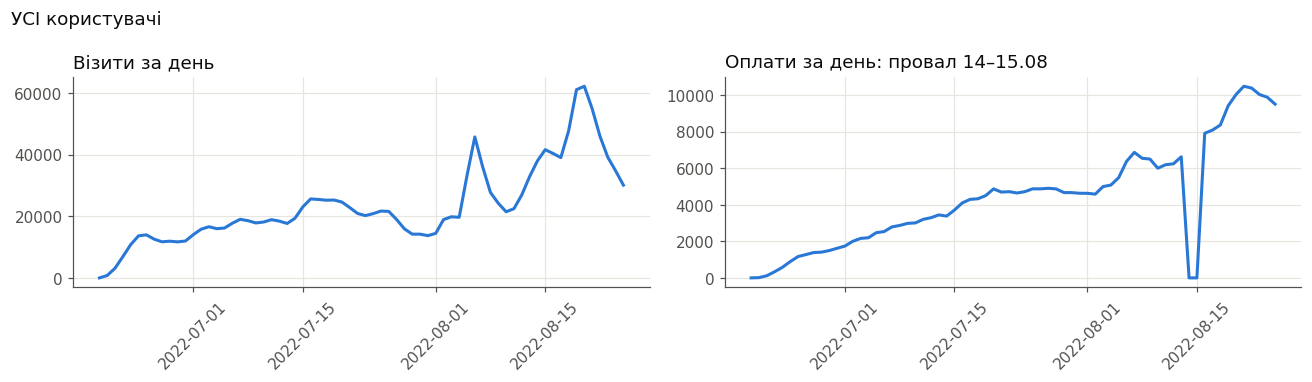

In [7]:
by_day = con.execute("""
    select v.date, v.visits, coalesce(t.payments, 0) as payments
    from (select date, count(*) as visits from visits group by date) v
    left join (select date, count(*) as payments from transactions group by date) t using (date)
    order by v.date
""").df()
by_day["date"] = pd.to_datetime(by_day.date)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)
axes[0].plot(by_day.date, by_day.visits, color="#2a78d6")
axes[1].plot(by_day.date, by_day.payments, color="#2a78d6")
axes[0].set_title("Візити за день", loc="left")
axes[1].set_title("Оплати за день: провал 14–15.08", loc="left")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("УСІ користувачі", x=0.01, ha="left")
fig.tight_layout()
fig.savefig(FIG / "eda_daily.png", bbox_inches="tight")

**2.5 Реєстрації по днях.** Піки 05–06.08 і 18–20.08; частка b стрибає з 30% до 50% саме 01.08.

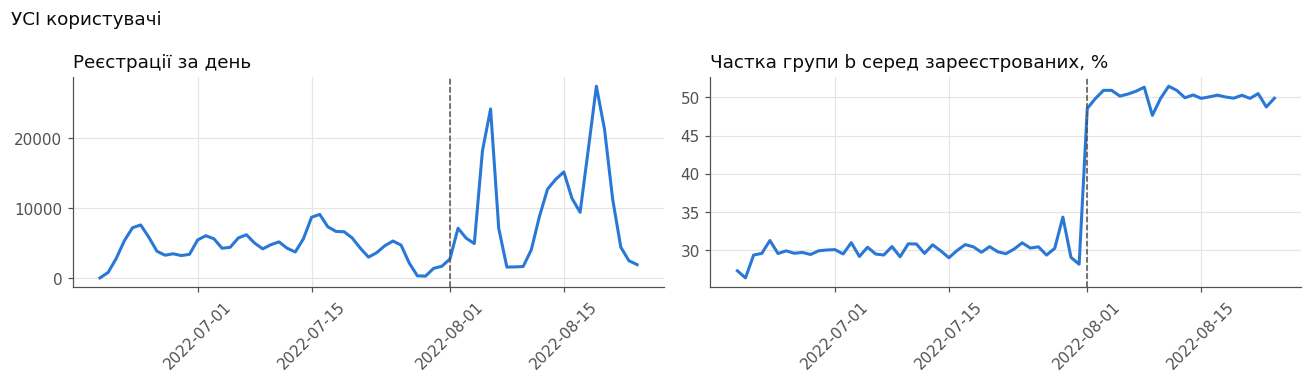

In [8]:
users["is_b"] = users.split_group == "b"
reg = users.groupby("reg_date").agg(registrations=("id", "size"), share_b=("is_b", "mean"))
reg["share_b"] = 100 * reg.share_b

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)
axes[0].plot(reg.index, reg.registrations, color="#2a78d6")
axes[1].plot(reg.index, reg.share_b, color="#2a78d6")
axes[0].set_title("Реєстрації за день", loc="left")
axes[1].set_title("Частка групи b серед зареєстрованих, %", loc="left")
for ax in axes:
    ax.axvline(pd.Timestamp("2022-08-01"), color="#52514e", lw=1, ls="--")
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("УСІ користувачі", x=0.01, ha="left")
fig.tight_layout()
fig.savefig(FIG / "eda_registrations.png", bbox_inches="tight")

**2.6 Старі до тесту.** Липень, користувачі з реєстрацією до 01.07: у групі b вища виручка й активність — і серед тих, хто імейлів не отримує. Отже, це різниця складу груп, а не ефект імейлів; тому для старих порівнюємо зміну відносно бази (CUPED).

**Висновок щодо CUPED:** для старих його варто застосувати — групи нерівні ще до тесту, а CUPED вирівнює їх за поведінкою 18–31.07. Для нових неможливий: до реєстрації даних нема.

In [9]:
july = con.execute("""
    with revenue as (
        select user_id, sum(amount) as revenue from transactions
        where date between date '2022-07-01' and date '2022-07-31' group by user_id
    ),
    visits_july as (
        select user_id, count(*) as visits from visits
        where date between date '2022-07-01' and date '2022-07-31' group by user_id
    )
    select u.id, u.split_group, u.is_validated,
           coalesce(r.revenue, 0) as revenue,
           coalesce(v.visits, 0)  as visits
    from read_csv_auto('users.csv') u
    left join revenue r     on r.user_id = u.id
    left join visits_july v on v.user_id = u.id
    where u.created_at < date '2022-07-01'
""").df()

rows = {}
for consent, g in july.groupby("is_validated"):
    for m in ["revenue", "visits"]:
        a, b = g.loc[g.split_group == "a", m], g.loc[g.split_group == "b", m]
        rows[("consent" if consent else "control", m)] = {
            "a": a.mean(), "b": b.mean(), "diff_pct": 100 * (b.mean() / a.mean() - 1)}
pd.DataFrame(rows).T

a     b  diff_pct
control revenue 10.94 13.01     18.96
        visits   1.47  1.55      5.08
consent revenue 12.34 16.11     30.51
        visits   2.63  2.73      3.66

**2.7 Концентрація виручки.** Невелика частка платників дає більшу частину виручки — тому найбільших платників обрізаємо (розділ 4).

In [10]:
payer_revenue = con.execute("select user_id, sum(amount) as revenue from transactions group by user_id").df().revenue
payer_revenue = payer_revenue.sort_values(ascending=False)
pd.Series({
    "payers_share_pct": 100 * len(payer_revenue) / len(users),
    "revenue_share_top1pct_payers": 100 * payer_revenue.head(len(payer_revenue) // 100).sum() / payer_revenue.sum(),
    "revenue_share_top10pct_payers": 100 * payer_revenue.head(len(payer_revenue) // 10).sum() / payer_revenue.sum(),
})

payers_share_pct                 4.97
revenue_share_top1pct_payers    11.08
revenue_share_top10pct_payers   50.99
dtype: float64

**2.8 Відтік.** Більшість користувачів швидко перестає заходити — тому активні дні окрема метрика. Користувачі з реєстрацією до 15.07.

In [11]:
retention = con.execute("""
    select datediff('day', cast(u.created_at as date), v.date) as day_n,
           count(distinct v.user_id) * 100.0 / (select count(*) from read_csv_auto('users.csv') where created_at < date '2022-07-15') as share
    from read_csv_auto('users.csv') u join visits v on v.user_id = u.id
    where u.created_at < date '2022-07-15'
    group by day_n
""").df().set_index("day_n").share
retention.reindex([1, 7, 14, 30]).rename("returned_on_day_pct")

day_n
1    46.64
7    13.73
14    8.20
30    2.32
Name: returned_on_day_pct, dtype: float64

## 3. Метрики користувачів

- **Нові:** реєстрація 01–19.08; метрики за перші 7 днів від реєстрації.
- **Старі:** реєстрація до 01.08; метрики за 01–25.08 і за 18–31.07 — період до тесту («база»).
- **Метрики:** виручка (без 14–15.08), платив чи ні, скільки днів заходив, скільки епізодів прочитав.
- **Зі згодою на імейли** — основний аналіз; **без згоди** — контроль: їм імейли не приходять.

In [12]:
# порядок рядків фіксований, щоб бутстреп давав ті самі числа при кожному запуску
user_metrics = con.execute("select * from user_metrics order by id").df()
user_metrics["reg_date"] = pd.to_datetime(user_metrics.reg_date)
for c in ["payer", "payer_base"]:
    user_metrics[c] = user_metrics[c].astype(float)

user_metrics.groupby(["population", "consent", "split_group"]).size().unstack()

split_group             a      b
population consent              
new        consent  34273  34237
           control  63591  64431
old        consent  47469  20345
           control  87699  37470

## 4. Обрізання найбільших платників
Виручка вище 99,9-го перцентиля рахується на рівні порогу. Поріг спільний для a і b в межах популяції та згоди.

In [13]:
def cap_threshold(df, col):
    # поріг кожної людини — 99,9-й перцентиль її популяції
    return df.groupby(["population", "consent"])[col].transform(lambda s: s.quantile(CAP_Q))

user_metrics["revenue_raw"] = user_metrics.revenue
user_metrics["revenue_cap"] = cap_threshold(user_metrics, "revenue_raw")
user_metrics["revenue"] = user_metrics.revenue_raw.clip(upper=user_metrics.revenue_cap)
user_metrics["revenue_base"] = user_metrics.revenue_base.clip(upper=cap_threshold(user_metrics, "revenue_base"))  # у нових бази нема

user_metrics["above_cap"] = user_metrics.revenue_raw > user_metrics.revenue_cap
cap_report = user_metrics.groupby(["population", "consent"]).agg(
    cap=("revenue_cap", "first"),
    users_above_cap=("above_cap", "sum"),
    revenue_raw=("revenue_raw", "sum"),
    revenue_capped=("revenue", "sum"),
)
cap_report["revenue_cut_pct"] = 100 * (1 - cap_report.revenue_capped / cap_report.revenue_raw)
cap_report[["cap", "users_above_cap", "revenue_cut_pct"]]

cap  users_above_cap  revenue_cut_pct
population consent                                           
new        consent   360.00               59             1.36
           control   360.00              112             1.23
old        consent 1,060.00               67             1.14
           control 1,010.00              122             1.33

## 5. Оцінка ефекту
- Ефект метрики — (середнє b − середнє a) / середнє a, %.
- Старі — з CUPED: від метрики в тесті віднімається частина, передбачувана тією ж метрикою в базі 18–31.07; коефіцієнт спільний для a і b.
- Бал = 0,5 · виручка + 0,2 · платники + 0,3 · активні дні. Епізоди — лише залученість, у бал не входять.
- Інтервали — бутстреп: 10 000 разів тягнемо людей кожної групи з поверненням і перераховуємо все; середні 95% результатів — інтервал.

In [14]:
def to_arrays(df, metrics, cuped):
    # колонки кожної групи як масиви чисел — так бутстреп швидкий
    if cuped:
        cols = metrics + [m + "_base" for m in metrics]
    else:
        cols = metrics
    return {g: {c: d[c].to_numpy(float) for c in cols} for g, d in df.groupby("split_group")}


def group_effects(a, b, metrics, cuped):
    # ефект b проти a, %, для кожної метрики і бал
    out = {}
    for m in metrics:
        mean_a, mean_b = a[m].mean(), b[m].mean()
        if cuped:
            # прибираємо різницю між групами, яка була ще до тесту
            x = np.concatenate([a[m + "_base"], b[m + "_base"]])
            y = np.concatenate([a[m], b[m]])
            theta = np.cov(x, y)[0, 1] / np.var(x, ddof=1)   # на скільки більше в тесті, якщо в базі на 1 більше
            mean_a -= theta * (a[m + "_base"].mean() - x.mean())
            mean_b -= theta * (b[m + "_base"].mean() - x.mean())
        out[m] = 100 * (mean_b / mean_a - 1)
    if all(m in metrics for m in WEIGHTS):
        out["score"] = sum(WEIGHTS[m] * out[m] for m in WEIGHTS)
    return out


def resample(group, n, rng):
    # витяг із поверненням: n людей, хтось двічі, хтось жодного разу
    idx = rng.integers(0, n, n)
    return {c: v[idx] for c, v in group.items()}


def rel_effects(df, cuped, n_boot=N_BOOT, seed=42, metrics=METRICS):
    rng = np.random.default_rng(seed)
    groups = to_arrays(df, metrics, cuped)
    n_a, n_b = (df.split_group == "a").sum(), (df.split_group == "b").sum()
    point = pd.Series(group_effects(groups["a"], groups["b"], metrics, cuped))
    draws = []
    for _ in range(n_boot):
        draws.append(group_effects(resample(groups["a"], n_a, rng), resample(groups["b"], n_b, rng), metrics, cuped))
    return point, pd.DataFrame(draws)


def summarize(point, draws):
    lo, hi = draws.quantile(0.025), draws.quantile(0.975)
    # p: як часто ефект опинявся по інший бік нуля, ×2 — бо міг бути і плюс, і мінус
    p = 2 * np.minimum((draws <= 0).mean(), (draws >= 0).mean()).clip(upper=0.5)
    return pd.DataFrame({"effect_pct": point, "ci_low": lo, "ci_high": hi,
                         "se": draws.std(), "p": p})


# (популяція, згода, чи CUPED); CUPED — лише старим, у нових нема бази
SLICES = [("new", "consent", False), ("old", "consent", True),
          ("new", "control", False), ("old", "control", True)]
est = {}
for pop, consent, cuped in SLICES:
    df = user_metrics[(user_metrics.population == pop) & (user_metrics.consent == consent)]
    point, draws = rel_effects(df, cuped)
    est[(pop, consent)] = {"point": point, "draws": draws, "n": len(df)}

In [15]:
tables = {}
for consent in ["consent", "control"]:
    new, old = est[("new", consent)], est[("old", consent)]
    tables[(consent, "new")] = summarize(new["point"], new["draws"])
    tables[(consent, "old")] = summarize(old["point"], old["draws"])

    # загальний бал: бал нових і старих, зважений за кількістю людей
    w_new = new["n"] / (new["n"] + old["n"])
    total_point = w_new * new["point"][["score"]] + (1 - w_new) * old["point"][["score"]]
    total_draws = w_new * new["draws"][["score"]] + (1 - w_new) * old["draws"][["score"]]
    tables[(consent, "total")] = summarize(total_point, total_draws)

effects = pd.concat(tables, names=["consent", "population", "metric"])
effects

effect_pct  ci_low  ci_high   se    p
consent population metric                                            
consent new        revenue            6.04   -3.43    16.53 5.05 0.22
                   payer              2.52   -4.09     9.41 3.46 0.47
                   active_days        6.48    5.75     7.22 0.37 0.00
                   episodes           6.24    4.45     8.06 0.92 0.00
                   score              5.47   -0.40    11.79 3.09 0.07
        old        revenue           -7.12  -11.96    -1.81 2.61 0.01
                   payer              1.02   -1.40     3.44 1.25 0.42
                   active_days       -3.26   -6.10    -0.39 1.45 0.03
                   episodes         -12.33  -15.81    -8.67 1.83 0.00
                   score             -4.34   -7.28    -1.16 1.56 0.01
        total      score              0.59   -2.67     4.17 1.74 0.72
control new        revenue           -1.37   -8.02     6.04 3.64 0.72
                   payer              1.89   -2.89     6.89 2.52 0.46
                   active_days        0.29   -0.27     0.87 0.29 0.31
                   episodes           0.33   -1.09     1.79 0.74 0.65
                   score             -0.22   -4.35     4.34 2.23 0.93
        old        revenue           -0.10   -4.25     4.26 2.17 0.94
                   payer             -0.97   -3.60     1.69 1.36 0.48
                   active_days        1.45   -1.70     4.80 1.66 0.38
                   episodes          -0.84   -4.34     2.77 1.83 0.64
                   score              0.19   -2.58     3.08 1.44 0.91
        total      score             -0.02   -2.56     2.73 1.35 1.00

## 6. Перевірки довіри
- **Контроль:** у користувачів без згоди на листи бал має бути ≈ 0 (95% інтервал містить 0).
- **Протилежні ефекти:** бали нових і старих мають різний знак, і обидва інтервали не містять 0.

In [16]:
def ci_contains_zero(consent, pop, metric="score"):
    r = effects.loc[(consent, pop, metric)]
    return r["ci_low"] <= 0 <= r["ci_high"]

control_ok = {pop: ci_contains_zero("control", pop) for pop in ["new", "old", "total"]}

s_new, s_old = effects.loc[("consent", "new", "score")], effects.loc[("consent", "old", "score")]
# протилежні: різні знаки, і обидва інтервали не містять 0
opposite = (s_new["effect_pct"] * s_old["effect_pct"] < 0
            and not ci_contains_zero("consent", "new") and not ci_contains_zero("consent", "old"))

pd.Series({"control_new_ci_contains_0": control_ok["new"],
           "control_old_ci_contains_0": control_ok["old"],
           "control_total_ci_contains_0": control_ok["total"],
           "proved_opposite_effects": opposite})

control_new_ci_contains_0       True
control_old_ci_contains_0       True
control_total_ci_contains_0     True
proved_opposite_effects        False
dtype: bool

## 7. Рекомендація за правилом протоколу (8.5)
Правило дає «не надсилати частіше старим»: у них менше активних днів. Для нових правило відповіді не дає — їхній бал не доведений. Тому рішення для нових ухвалене окремо (розділ 12).

In [17]:
def recommend(pop):
    # вердикт за правилом протоколу окремо для нових і старих
    score = effects.loc[("consent", pop, "score")]
    active = effects.loc[("consent", pop, "active_days")]

    if not all(control_ok.values()):
        return "контроль показав ефект — результат не інтерпретуємо, доки не знайдено причину"
    if active["ci_high"] < 0:
        return "заборона: активні дні знизились — не надсилати частіше"
    if score["ci_low"] > 0:
        return "надсилати імейли частіше"
    if score["ci_high"] < 0:
        return "не надсилати частіше"
    return "ефект не доведений — продовжити тест"


pd.Series({"new": recommend("new"), "old": recommend("old")}, name="recommendation")

new                 ефект не доведений — продовжити тест
old    заборона: активні дні знизились — не надсилати...
Name: recommendation, dtype: object

## 8. Графік ефектів

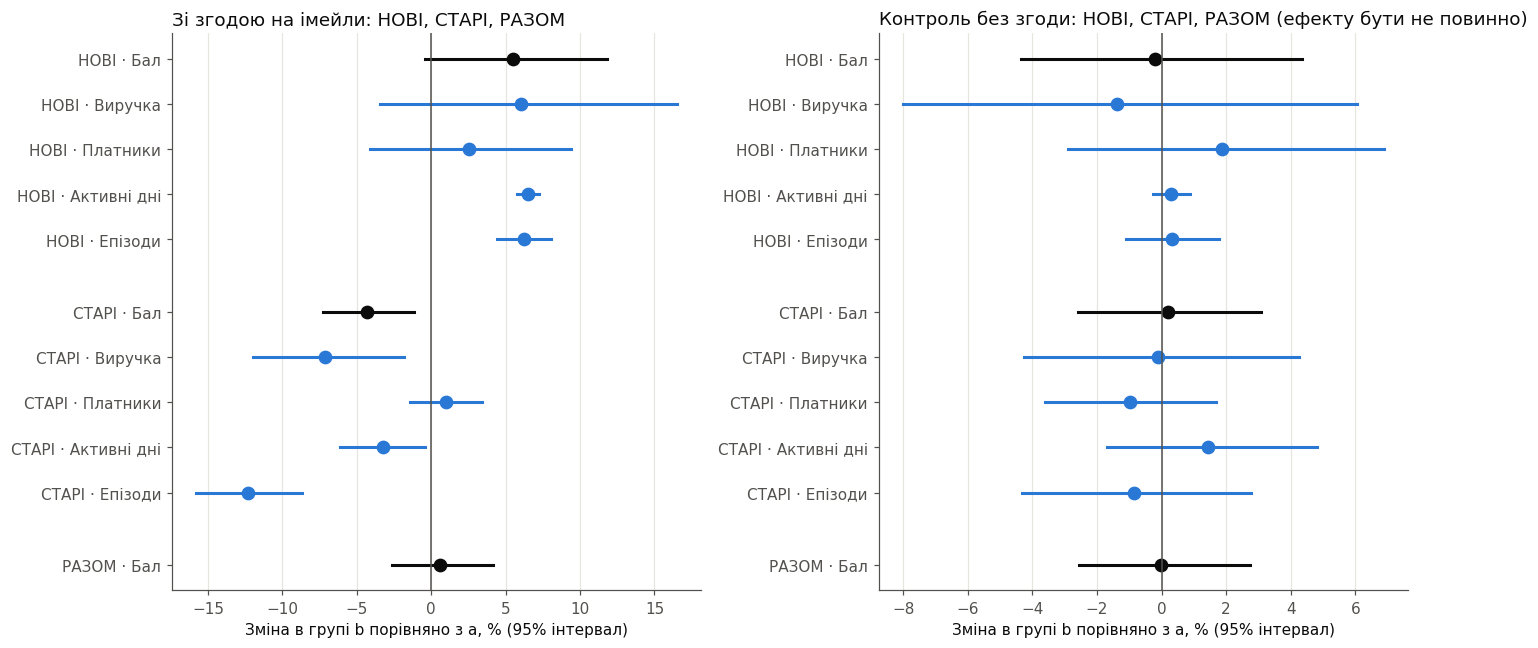

In [18]:
def forest(ax, consent, title):
    labels = {"revenue": "Виручка", "payer": "Платники", "active_days": "Активні дні",
              "episodes": "Епізоди", "score": "Бал"}
    pops = {"new": "НОВІ", "old": "СТАРІ", "total": "РАЗОМ"}
    y, ticks = 0, []
    for pop in ["new", "old", "total"]:
        for m in ["score", "revenue", "payer", "active_days", "episodes"]:
            if (consent, pop, m) not in effects.index:
                continue
            r = effects.loc[(consent, pop, m)]
            color = "#0b0b0b" if m == "score" else "#2a78d6"
            ax.plot([r["ci_low"], r["ci_high"]], [y, y], color=color, lw=2)
            ax.plot(r["effect_pct"], y, "o", color=color, ms=8)
            ticks.append((y, f"{pops[pop]} · {labels[m]}"))
            y -= 1
        y -= 0.6
    ax.axvline(0, color="#52514e", lw=1)
    ax.set_yticks([t[0] for t in ticks], [t[1] for t in ticks])
    ax.set_xlabel("Зміна в групі b порівняно з a, % (95% інтервал)")
    ax.set_title(title, loc="left")
    ax.grid(axis="y", visible=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=False)
forest(axes[0], "consent", "Зі згодою на імейли: НОВІ, СТАРІ, РАЗОМ")
forest(axes[1], "control", "Контроль без згоди: НОВІ, СТАРІ, РАЗОМ (ефекту бути не повинно)")
fig.tight_layout()
fig.savefig(FIG / "effects.png", bbox_inches="tight")

## 9. Когортна динаміка
**Нові:** частка тих, хто зайшов у день N після реєстрації, і накопичена виручка на користувача (зі згодою на листи). Криві описові, без інтервалів.

day_n                     0     1     2     3     4     5     6
reg_week split_group                                           
01–07.08 a           100.00 51.63 38.19 30.86 26.69 21.89 19.73
         b           100.00 58.19 41.39 34.08 28.39 25.46 22.28
08–14.08 a           100.00 53.15 37.58 29.97 27.18 22.96 19.80
         b           100.00 58.25 42.57 34.06 28.58 23.87 21.58
15–19.08 a           100.00 51.90 38.06 30.73 26.02 23.60 20.49
         b           100.00 58.01 42.02 33.83 28.04 24.37 21.84

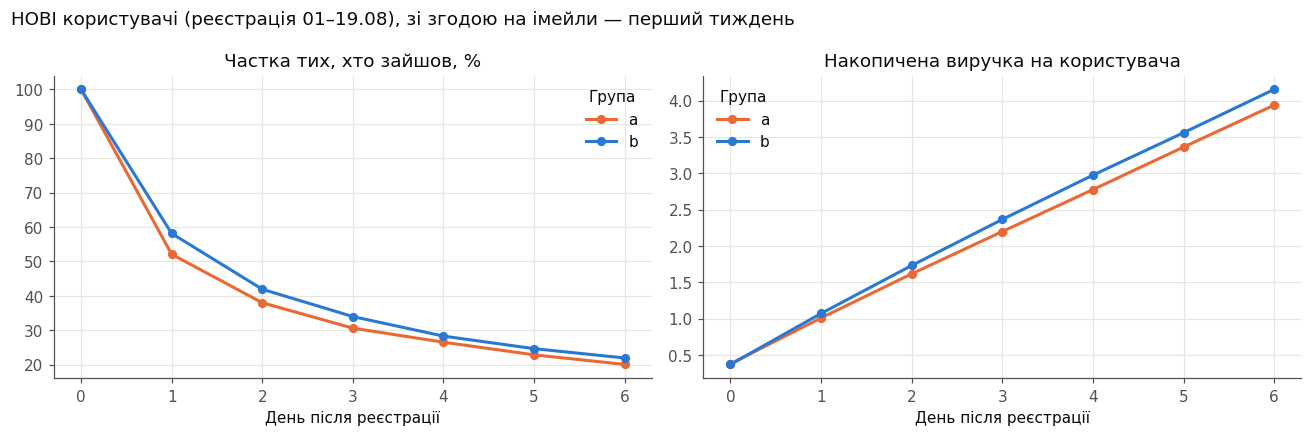

In [19]:
daily_new = con.execute("select * from daily_new where consent = 'consent'").df()
agg = daily_new.groupby(["split_group", "day_n"])[["users", "active_users", "revenue"]].sum().reset_index()
agg["active_share"] = 100 * agg.active_users / agg.users
agg["cum_revenue"] = agg.groupby("split_group").revenue.cumsum() / agg.users

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for g, d in agg.groupby("split_group"):
    axes[0].plot(d.day_n, d.active_share, marker="o", ms=5, color=COLORS[g], label=g)
    axes[1].plot(d.day_n, d.cum_revenue, marker="o", ms=5, color=COLORS[g], label=g)
axes[0].set(title="Частка тих, хто зайшов, %", xlabel="День після реєстрації")
axes[1].set(title="Накопичена виручка на користувача", xlabel="День після реєстрації")
for ax in axes:
    ax.legend(title="Група", frameon=False)
fig.suptitle("НОВІ користувачі (реєстрація 01–19.08), зі згодою на імейли — перший тиждень", x=0.01, ha="left")
fig.tight_layout()
fig.savefig(FIG / "cohort_new.png", bbox_inches="tight")

by_week = daily_new.groupby(["reg_week", "split_group", "day_n"])[["users", "active_users"]].sum()
by_week["share"] = 100 * by_week.active_users / by_week.users
by_week.share.unstack("day_n")

**Нові після першого тижня (протокол 8.10):** реєстрація 01–07.08, дні 0–6 проти 7–17 від реєстрації.
Червоний прапорець — у днях 7–17 інтервал ефекту активних днів повністю нижче 0.

In [20]:
new_long = con.execute("select * from new_long where consent = 'consent' order by id").df()
long_tables = {}
for window in ["0_6", "7_17"]:
    window_df = pd.DataFrame({"split_group": new_long.split_group,
                              "active_days": new_long[f"active_{window}"],
                              "revenue": new_long[f"revenue_{window}"]})
    window_df["revenue"] = window_df.revenue.clip(upper=window_df.revenue.quantile(CAP_Q))
    point, draws = rel_effects(window_df, cuped=False, metrics=["active_days", "revenue"])
    long_tables[f"days_{window}"] = summarize(point, draws)
long_effects = pd.concat(long_tables, names=["window", "metric"])

late = long_effects.loc[("days_7_17", "active_days")]
if late["ci_high"] < 0:
    verdict = "червоний прапорець: після першого тижня b нижче a"
elif late["ci_low"] > 0:
    verdict = "приріст тримається"
else:
    verdict = "приріст згас до рівня a"
display(long_effects)
verdict

effect_pct  ci_low  ci_high   se    p
window    metric                                            
days_0_6  active_days        7.20    5.97     8.42 0.63 0.00
          revenue            6.44   -8.83    24.38 8.48 0.42
days_7_17 active_days        4.31    1.03     7.66 1.68 0.01
          revenue            1.21  -15.49    21.18 9.43 0.89

'приріст тримається'

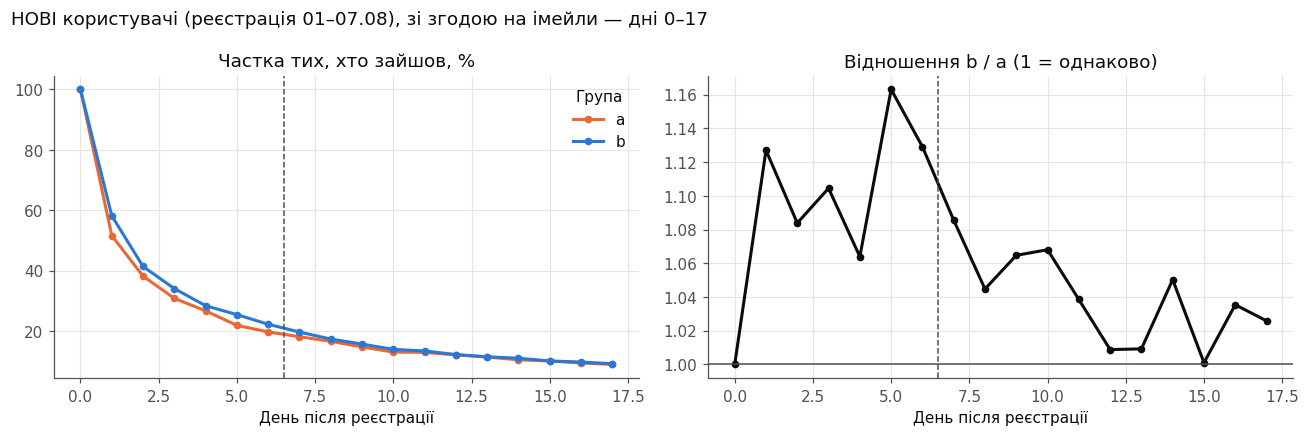

In [21]:
new_long_daily = con.execute("select * from new_long_daily where consent = 'consent'").df()
new_long_daily["share"] = 100 * new_long_daily.active_users / new_long_daily.users

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for g, d in new_long_daily.sort_values("day_n").groupby("split_group"):
    axes[0].plot(d.day_n, d.share, marker="o", ms=4, color=COLORS[g], label=g)
ratio = new_long_daily.pivot(index="day_n", columns="split_group", values="share")
axes[1].plot(ratio.index, ratio.b / ratio.a, marker="o", ms=4, color="#0b0b0b")
axes[1].axhline(1, color="#52514e", lw=1)
axes[0].set(title="Частка тих, хто зайшов, %", xlabel="День після реєстрації")
axes[1].set(title="Відношення b / a (1 = однаково)", xlabel="День після реєстрації")
axes[0].legend(title="Група", frameon=False)
for ax in axes:
    ax.axvline(6.5, color="#52514e", lw=1, ls="--")   # кінець першого тижня
fig.suptitle("НОВІ користувачі (реєстрація 01–07.08), зі згодою на імейли — дні 0–17", x=0.01, ha="left")
fig.tight_layout()
fig.savefig(FIG / "new_long.png", bbox_inches="tight")

**Старі:** частка активних і виручка на користувача за кожен день, відносно середнього дня бази 18–31.07 своєї групи (= 100). 14–15.08 у виручці пропущено — оплат у даних нема.

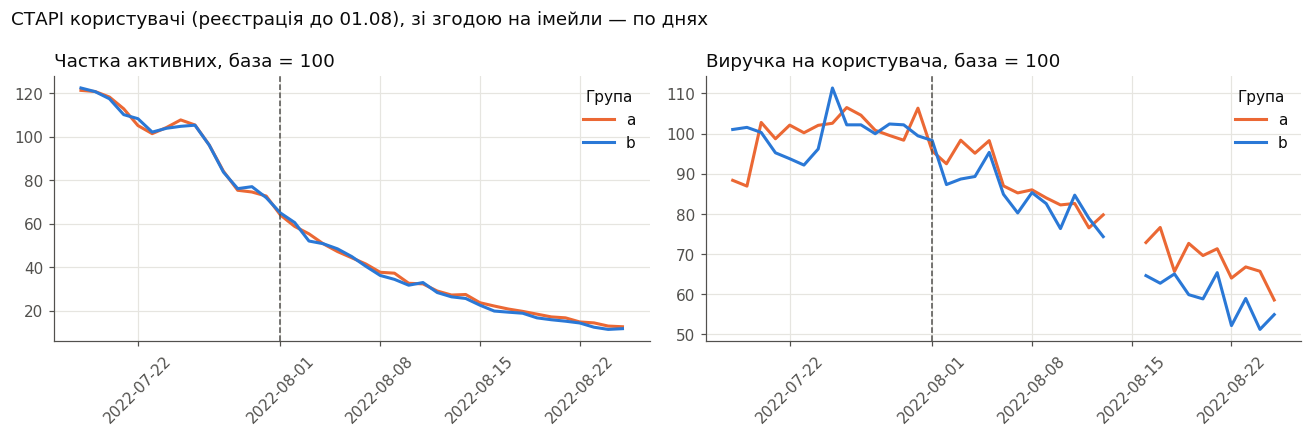

In [22]:
daily_old = con.execute("select * from daily_old where consent = 'consent'").df()
daily_old["date"] = pd.to_datetime(daily_old.date)
daily_old["active_share"] = daily_old.active_users / daily_old.users
daily_old["rev_per_user"] = daily_old.revenue / daily_old.users
daily_old.loc[daily_old.missing_revenue, "rev_per_user"] = np.nan
base = daily_old[~daily_old.is_test].groupby("split_group")[["active_share", "rev_per_user"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for g, d in daily_old.sort_values("date").groupby("split_group"):
    for ax, col, title in [(axes[0], "active_share", "Частка активних, база = 100"),
                           (axes[1], "rev_per_user", "Виручка на користувача, база = 100")]:
        ax.plot(d.date, 100 * d[col] / base.loc[g, col], color=COLORS[g], label=g)
        ax.set_title(title, loc="left")
for ax in axes:
    ax.axvline(pd.Timestamp("2022-08-01"), color="#52514e", lw=1, ls="--")
    ax.legend(title="Група", frameon=False)
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("СТАРІ користувачі (реєстрація до 01.08), зі згодою на імейли — по днях", x=0.01, ha="left")
fig.tight_layout()
fig.savefig(FIG / "daily_old.png", bbox_inches="tight")

## 10. Розрізи країна × ОС
Бал у кожному розрізі. «Надійно» — з урахуванням того, що розрізів 8 (поправка Голма).

In [23]:
def holm(p):
    # поправка Голма: що більше порівнянь, то суворіше до кожного
    return pd.Series(multipletests(p, method="holm")[1], index=p.index)

seg_rows = {}
for pop, cuped in [("new", False), ("old", True)]:
    people = user_metrics[(user_metrics.population == pop) & (user_metrics.consent == "consent")]
    for segment, df in people.groupby("segment"):
        point, draws = rel_effects(df, cuped)
        seg_rows[(pop, segment)] = summarize(point, draws).loc["score"]

seg = pd.DataFrame(seg_rows).T.astype(float)
seg["significant"] = np.where(holm(seg["p"]) < 0.05, "yes", "no")   # з урахуванням 8 порівнянь
seg[["effect_pct", "ci_low", "ci_high", "significant"]]

effect_pct  ci_low  ci_high significant
new country 1 / android       21.67    0.58    51.34          no
    country 2 / android        9.53   -0.22    21.07          no
    country 2 / ios            2.24   -7.13    13.24          no
    country 3 / desktop       -2.15  -12.67    10.19          no
old country 1 / android        4.66   -9.00    20.92          no
    country 2 / android       -3.35  -10.42     4.42          no
    country 2 / ios           -8.19  -12.50    -3.47         yes
    country 3 / desktop       -1.02   -5.76     4.15          no

## 11. Додаткові питання
1. **Чи достатньо даних?** Для старих — так: ефекти надійні. Для виручки нових — ні: діапазон −3…+17% зачіпає 0, тест для нових треба продовжити.
2. **Чи можна було закрити тест раніше?** Ні. Тест планувався на фіксований термін, а закриття щойно результат став значущим збільшує шанс хибного висновку.
3. **Чи варто застосувати CUPED?** Так, для старих: групи нерівні ще до тесту (розділ 2.6). Для нових неможливий — до реєстрації даних нема.
4. **Які дані допомогли б оцінити тест швидше?** Події самих імейлів — відправки, відкриття, кліки, відписки: реакцію на них видно в перші дні, раніше за виручку.

## 12. Висновки
**Рекомендація:** надсилати листи вдвічі частіше лише новим користувачам; старим лишити частоту як є; тест для нових продовжити, щоб перевірити ефект на виручку.

**Нові (перший тиждень):** активні дні +6,5%, епізоди +6,2% — доведено; виручка +6% — не доведено; бал +5,5% (p = 0,07) — на межі доведеного. У днях 7–17 перевага в активності тримається (+4,3%), поступово згасає, нижче a не падає. Рекомендація для нових спирається на активність, а не на виручку.

**Старі (01–25.08):** виручка −7%, активні дні −3%, епізоди −12% — доведено; найсильніше на iOS. Частина негативу може бути реакцією на різку зміну частоти — стабільність покаже довший тест.

**Разом:** бал +0,6% — протилежні напрямки гасять одне одного.

**Додаткові питання:**
1. Чи достатньо даних: для старих — так; для виручки нових — ні.
2. Чи можна було закрити раніше: ні — тест мав фіксований термін.
3. CUPED: так для старих — групи нерівні ще до тесту; для нових неможливий.
4. Що прискорило б оцінку: події листів — відкриття, кліки, відписки.

**Довіра:** групи поділені коректно, дані звірені з сирими, у людей без згоди на листи ефекту нема.

**Обмеження:** даних про самі листи (відписки, скарги) нема — ризик втоми від розсилки видно лише через активність.